In [1]:
# importing required libs
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt 

df = pd.read_csv('csv_files/clean_loan_train.csv')
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,1,0,0,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,1,0,0,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,1,0,0,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,1,0,0,1


##### 1. Splitting feature and the target

In [2]:
X = df.drop(columns=['Loan_Status'])  # the input
Y = df['Loan_Status']                 # the answer

##### 2. Training and testing splitting

In [3]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size = 0.2,
    random_state = 42    
)

##### 3. Training a logistic regression model

In [4]:
model = LogisticRegression(max_iter=50000, random_state=42)

model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [5]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(Y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 78.86%


#### Confusion matrix

In [6]:
matrix= confusion_matrix(Y_test, y_pred)

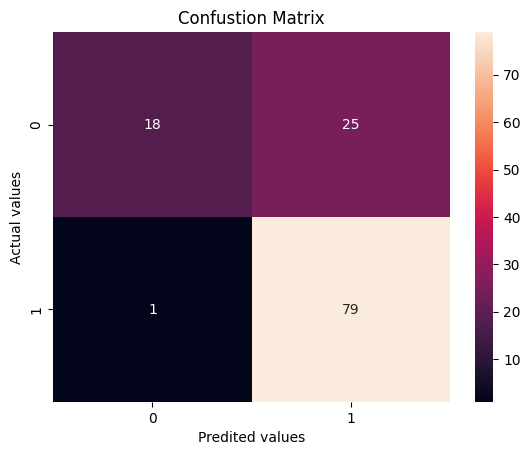

In [7]:
# Vizualizing the matrix
sns.heatmap(matrix, annot = True)
plt.title('Confustion Matrix')
plt.xlabel('Predited values')
plt.ylabel('Actual values')
plt.show()

#### What Each Number Means
##### 18 — True Negatives 
18 people who were actually going to default, the model correctly predicted they'd default and rejected them. Good catch.

##### 79 — True Positives 
79 people who were actually creditworthy, the model correctly approved them. These are the easy wins.

##### 1 — False Negative (minor)
1 person who was actually a good applicant, but the model wrongly rejected them. The bank lost one customer. Not a big deal.

##### 25 — False Positives (THIS IS THE PROBLEM)
25 people who were actually going to default, but the model said, "Approve them." The bank gave loans to 25 risky people.

#### Classification Report

In [8]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



The classification report reveals that the model performs very differently across classes. 

For good applicants (class 1), recall is 0.99; it almost never misses a creditworthy person. 

But for defaulters (class 0), recall is only 0.42; it misses 58% of risky applicants. This is the real weakness.

In a banking context, class 0 recall is the most critical metric because every missed defaulter is a financial loss. The high overall accuracy of 79% is inflated by the model's strength on the majority class

#### Decision tree

In [11]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [13]:
from sklearn.metrics import accuracy_score

# Predict on training data
train_pred_dt = dt_model.predict(X_train)
train_acc_dt = accuracy_score(Y_train, train_pred_dt)

# Predict on test data
test_pred_dt = dt_model.predict(X_test)
test_acc_dt = accuracy_score(Y_test, test_pred_dt)

print(f"Decision Tree — Training Accuracy: {train_acc_dt:.2%}")
print(f"Decision Tree — Test Accuracy    : {test_acc_dt:.2%}")

Decision Tree — Training Accuracy: 100.00%
Decision Tree — Test Accuracy    : 69.11%


In [14]:
# Your logistic regression model from before
train_pred_lr = model.predict(X_train)
train_acc_lr = accuracy_score(Y_train, train_pred_lr)

test_pred_lr = model.predict(X_test)
test_acc_lr = accuracy_score(Y_test, test_pred_lr)

print(f"Logistic Regression — Training Accuracy: {train_acc_lr:.2%}")
print(f"Logistic Regression — Test Accuracy    : {test_acc_lr:.2%}")

Logistic Regression — Training Accuracy: 81.87%
Logistic Regression — Test Accuracy    : 78.86%


In [16]:
print("Decision Tree Classification Report:")
print(classification_report(Y_test, test_pred_dt))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.49      0.53        43
           1       0.74      0.80      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.64      0.65       123
weighted avg       0.68      0.69      0.69       123



The Decision Tree achieved 100% training accuracy but only 69% test accuracy, a 31% gap that clearly indicates overfitting. The model memorised the training data rather than learning generalisable patterns.

Logistic Regression, by contrast, showed only a 3% gap (81.87% vs 78.86%), confirming it generalised better to unseen data. While the Decision Tree marginally improved recall for defaulters (0.49 vs 0.42), this came at the cost of precision dropping from 0.95 to 0.57, meaning it wrongly flagged many good applicants as risky. 

For this dataset, Logistic Regression is the more reliable and production-worthy model

#####  Plotting feature importance of the decision tree

In [17]:
importances = dt_model.feature_importances_

In [18]:
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

In [19]:
importance_df = importance_df.sort_values('Importance', ascending=False)

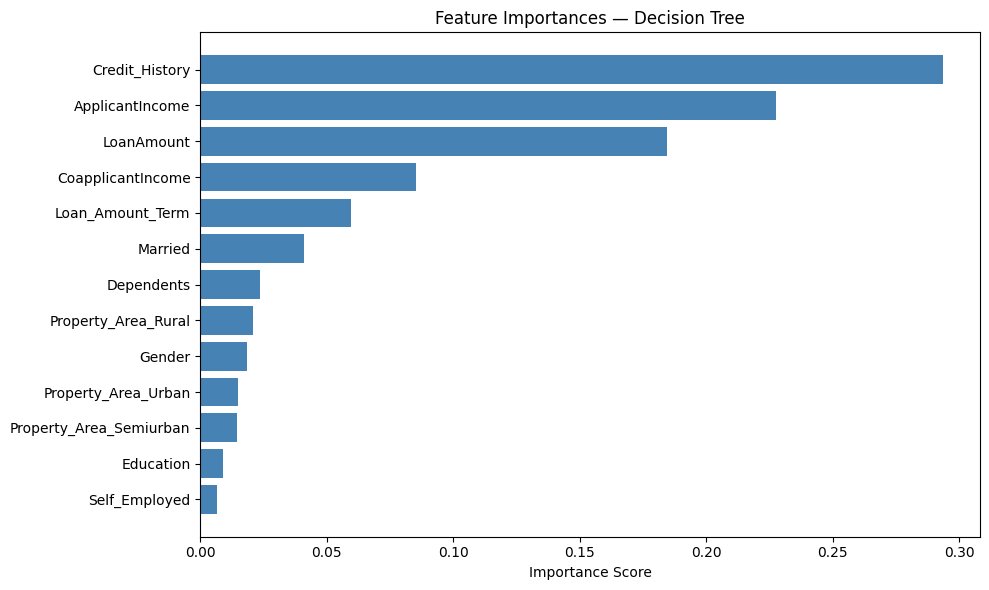

In [24]:

plt.figure(figsize=(10, 6))

plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')

plt.xlabel('Importance Score')
plt.title('Feature Importances — Decision Tree')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### The Real Decision Makers

### Credit_History → 0.30 (30%)
The single most powerful predictor by a wide margin. Nearly a third of all the tree's decisions were based on this one feature alone. This makes complete real-world sense a person's past repayment behaviour is the strongest signal of future behaviour. Every real bank checks this first.

### ApplicantIncome → 0.23 (23%)
Second most important. Higher income = more capacity to repay. The model independently discovered what banks have known for decades.

### LoanAmount → 0.19 (19%)
Third. Makes sense in combination with income — a small loan for a high-income person is low risk. A large loan for a low-income person is high risk. The tree likely uses these two together.

These three features alone account for 72% of all decision-making. Everything else is minor context.

The feature importance chart revealed that Credit History, Applicant Income, and Loan Amount together drove 72% of the model's decisions. This aligns with real banking logic; past repayment behaviour and current financial capacity are the strongest indicators of loan default risk. 

Interestingly, demographic features like Gender, Education, and Self-Employment status had near-zero importance, suggesting the model is making decisions based on financial merit rather than personal characteristics which is also an ethically desirable outcome